<a href="https://colab.research.google.com/github/Nirmalkumarganesan95/PySPark/blob/main/Pyspark_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
import pyspark
pyspark.__version__

'4.0.3'

#Create an Empty DataFrame

In [ ]:
#1. Create Empty RDD in PySpark
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

In [ ]:
#create empty RDD
empty_rrd = spark.sparkContext.emptyRDD()
print(empty_rrd)

EmptyRDD[0] at emptyRDD at NativeMethodAccessorImpl.java:0


In [ ]:
rdd2 = spark.sparkContext.parallelize([])
print(rdd2)

ParallelCollectionRDD[1] at readRDDFromFile at PythonRDD.scala:297


In [ ]:
#2. Create Empty DataFrame with Schema (StructType)
from pyspark.sql.types import StructType, StringType, StructField
schema = StructType([
    StructField("firstname", StringType(), True),
    StructField('middlename', StringType(), True),
    StructField("lastname", StringType(), True)
                     ])

In [ ]:
##Create empty DataFrame from empty RDD
df = spark.createDataFrame(empty_rrd, schema)
df.printSchema()

root
 |-- firstname: string (nullable = true)
 |-- middlename: string (nullable = true)
 |-- lastname: string (nullable = true)



In [ ]:
#3. Convert Empty RDD to DataFrame
df1 = empty_rrd.toDF(schema)
df1.printSchema

<bound method DataFrame.printSchema of DataFrame[firstname: string, middlename: string, lastname: string]>

In [ ]:
#4. Create Empty DataFrame with Schema.
df2 = spark.createDataFrame([], schema)
df2.printSchema

<bound method DataFrame.printSchema of DataFrame[firstname: string, middlename: string, lastname: string]>

In [ ]:
#5. Create Empty DataFrame without Schema (no columns)
#Create empty DatFrame with no schema (no columns)
df3 = spark.createDataFrame([], StructType([]))
df3.printSchema()

root



#Convert PySpark RDD to DataFrame

In [ ]:
#1. Create PySpark RDD
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()
dept = [("Finance",10),("Marketing",20),("Sales",30),("IT",40)]
rdd = spark.sparkContext.parallelize(dept)

In [ ]:
#2. Convert PySpark RDD to DataFrame
df = rdd.toDF()
df.printSchema()
df.show(truncate=False)

root
 |-- _1: string (nullable = true)
 |-- _2: long (nullable = true)

+---------+---+
|_1       |_2 |
+---------+---+
|Finance  |10 |
|Marketing|20 |
|Sales    |30 |
|IT       |40 |
+---------+---+



In [ ]:
dept_column = ["dept_name", "dept_id"]
df2 = rdd.toDF(dept_column)
df2.printSchema()
df2.show(truncate=False)

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: long (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



In [ ]:
#2.2 Using PySpark createDataFrame() function
deptdf = spark.createDataFrame(rdd, schema=dept_column)
deptdf.printSchema()
deptdf.show(truncate = False)

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: long (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



In [ ]:
#2.3 Using createDataFrame() with StructType schema
from pyspark.sql.types import StructType,StructField, StringType
deptSchema = StructType([
    StructField('dept_name', StringType(), True),
    StructField('dept_id', StringType(), True)
])

deptDF1 = spark.createDataFrame(rdd, schema = deptSchema)
deptDF1.printSchema()
deptDF1.show(truncate=False)

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: string (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



In [ ]:
#3. Complete Example
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

dept = [("Finance",10),("Marketing",20),("Sales",30),("IT",40)]
rdd = spark.sparkContext.parallelize(dept)

df = rdd.toDF()
df.printSchema()
df.show(truncate=False)

deptColumns = ["dept_name","dept_id"]
df2 = rdd.toDF(deptColumns)
df2.printSchema()
df2.show(truncate=False)

deptDF = spark.createDataFrame(rdd, schema = deptColumns)
deptDF.printSchema()
deptDF.show(truncate=False)

from pyspark.sql.types import StructType,StructField, StringType
deptSchema = StructType([
    StructField('dept_name', StringType(), True),
    StructField('dept_id', StringType(), True)
])

deptDF1 = spark.createDataFrame(rdd, schema = deptSchema)
deptDF1.printSchema()
deptDF1.show(truncate=False)

root
 |-- _1: string (nullable = true)
 |-- _2: long (nullable = true)

+---------+---+
|_1       |_2 |
+---------+---+
|Finance  |10 |
|Marketing|20 |
|Sales    |30 |
|IT       |40 |
+---------+---+

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: long (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: long (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: string (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



#Convert PySpark DataFrame to Pandas


**Key Points –**

* Use the toPandas() method available in PySpark DataFrame objects to convert them to DataFrames.
* Pandas DataFrames are in-memory data structures, so consider memory constraints when converting large PySpark DataFrames.
* Converting PySpark DataFrames to Pandas DataFrames allows you to leverage Pandas’ extensive functionality for data manipulation and analysis.

In [ ]:
#Prepare PySpark DataFrame
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

data = [("James","","Smith","36636","M",60000),
        ("Michael","Rose","","40288","M",70000),
        ("Robert","","Williams","42114","",400000),
        ("Maria","Anne","Jones","39192","F",500000),
        ("Jen","Mary","Brown","","F",0)]

columns = ["first_name","middle_name","last_name","dob","gender","salary"]

pysparkdf = spark.createDataFrame(data = data, schema = columns)
pysparkdf.printSchema()
pysparkdf.show(truncate=False)

root
 |-- first_name: string (nullable = true)
 |-- middle_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: long (nullable = true)

+----------+-----------+---------+-----+------+------+
|first_name|middle_name|last_name|dob  |gender|salary|
+----------+-----------+---------+-----+------+------+
|James     |           |Smith    |36636|M     |60000 |
|Michael   |Rose       |         |40288|M     |70000 |
|Robert    |           |Williams |42114|      |400000|
|Maria     |Anne       |Jones    |39192|F     |500000|
|Jen       |Mary       |Brown    |     |F     |0     |
+----------+-----------+---------+-----+------+------+



In [ ]:
#Convert PySpark Dataframe to Pandas DataFrame
pandasdf = pysparkdf.toPandas()
print(pandasdf)

  first_name middle_name last_name    dob gender  salary
0      James                 Smith  36636      M   60000
1    Michael        Rose            40288      M   70000
2     Robert              Williams  42114         400000
3      Maria        Anne     Jones  39192      F  500000
4        Jen        Mary     Brown             F       0


In [ ]:
#Convert Spark Nested Struct DataFrame to Pandas
# Nested structure elements
from pyspark.sql.types import StructType, StructField, StringType,IntegerType
dataStruct = [(("James","","Smith"),"36636","M","3000"), \
      (("Michael","Rose",""),"40288","M","4000"), \
      (("Robert","","Williams"),"42114","M","4000"), \
      (("Maria","Anne","Jones"),"39192","F","4000"), \
      (("Jen","Mary","Brown"),"","F","-1") \
]

schemaStruct = StructType([
        StructField('name', StructType([
             StructField('firstname', StringType(), True),
             StructField('middlename', StringType(), True),
             StructField('lastname', StringType(), True)
             ])),
          StructField('dob', StringType(), True),
         StructField('gender', StringType(), True),
         StructField('salary', StringType(), True)
         ])
df = spark.createDataFrame(data=dataStruct, schema = schemaStruct)
df.printSchema()

pandasDF2 = df.toPandas()
print(pandasDF2)

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string (nullable = true)
 |    |-- lastname: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: string (nullable = true)

                   name    dob gender salary
0      (James, , Smith)  36636      M   3000
1     (Michael, Rose, )  40288      M   4000
2  (Robert, , Williams)  42114      M   4000
3  (Maria, Anne, Jones)  39192      F   4000
4    (Jen, Mary, Brown)             F     -1


#PySpark show() – Display DataFrame Contents in Table

In [ ]:
#1. Quick Example of show()
# Default - displays 20 rows and
# 20 charactes from column value
df.show()

#Display full column contents
df.show(truncate=False)

# Display 2 rows and full column contents
df.show(2,truncate=False)

# Display 2 rows & column values 25 characters
df.show(2,truncate=25)

# Display DataFrame rows & columns vertically
df.show(n=3,truncate=25,vertical=True)

+--------------------+-----+------+------+
|                name|  dob|gender|salary|
+--------------------+-----+------+------+
|    {James, , Smith}|36636|     M|  3000|
|   {Michael, Rose, }|40288|     M|  4000|
|{Robert, , Williams}|42114|     M|  4000|
|{Maria, Anne, Jones}|39192|     F|  4000|
|  {Jen, Mary, Brown}|     |     F|    -1|
+--------------------+-----+------+------+

+--------------------+-----+------+------+
|name                |dob  |gender|salary|
+--------------------+-----+------+------+
|{James, , Smith}    |36636|M     |3000  |
|{Michael, Rose, }   |40288|M     |4000  |
|{Robert, , Williams}|42114|M     |4000  |
|{Maria, Anne, Jones}|39192|F     |4000  |
|{Jen, Mary, Brown}  |     |F     |-1    |
+--------------------+-----+------+------+

+-----------------+-----+------+------+
|name             |dob  |gender|salary|
+-----------------+-----+------+------+
|{James, , Smith} |36636|M     |3000  |
|{Michael, Rose, }|40288|M     |4000  |
+-----------------+-----

In [ ]:
#2. show() Syntax
def show(self, n=20, truncate=True, vertical=False):

In [ ]:
#3. PySpark show() To Display Contents
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()
columns = ["Seqno","Quote"]
data = [("1", "Be the change that you wish to see in the world"),
    ("2", "Everyone thinks of changing the world, but no one thinks of changing himself."),
    ("3", "The purpose of our lives is to be happy."),
    ("4", "Be cool.")]
df = spark.createDataFrame(data,columns)
df.show()

+-----+--------------------+
|Seqno|               Quote|
+-----+--------------------+
|    1|Be the change tha...|
|    2|Everyone thinks o...|
|    3|The purpose of ou...|
|    4|            Be cool.|
+-----+--------------------+



In [ ]:
#Display full column contents
df.show(truncate=False)

+-----+-----------------------------------------------------------------------------+
|Seqno|Quote                                                                        |
+-----+-----------------------------------------------------------------------------+
|1    |Be the change that you wish to see in the world                              |
|2    |Everyone thinks of changing the world, but no one thinks of changing himself.|
|3    |The purpose of our lives is to be happy.                                     |
|4    |Be cool.                                                                     |
+-----+-----------------------------------------------------------------------------+



In [ ]:
# Display 2 rows and full column contents
df.show(2,truncate=False)

+-----+-----------------------------------------------------------------------------+
|Seqno|Quote                                                                        |
+-----+-----------------------------------------------------------------------------+
|1    |Be the change that you wish to see in the world                              |
|2    |Everyone thinks of changing the world, but no one thinks of changing himself.|
+-----+-----------------------------------------------------------------------------+
only showing top 2 rows


In [ ]:
#4. Show() with Truncate Column Values
# Display 2 rows & column values 25 characters
df.show(2, truncate=25)

+-----+-------------------------+
|Seqno|                    Quote|
+-----+-------------------------+
|    1|Be the change that you...|
|    2|Everyone thinks of cha...|
+-----+-------------------------+
only showing top 2 rows


In [ ]:
#5. Display Contents Vertically
df.show(truncate=False, vertical=True)

-RECORD 0------------------------------------------------------------------------------
 Seqno | 1                                                                             
 Quote | Be the change that you wish to see in the world                               
-RECORD 1------------------------------------------------------------------------------
 Seqno | 2                                                                             
 Quote | Everyone thinks of changing the world, but no one thinks of changing himself. 
-RECORD 2------------------------------------------------------------------------------
 Seqno | 3                                                                             
 Quote | The purpose of our lives is to be happy.                                      
-RECORD 3------------------------------------------------------------------------------
 Seqno | 4                                                                             
 Quote | Be cool.               

#PySpark StructType & StructField Explained with Examples

**Key Points:**

* StructType is a collection or list of StructField objects.
* **Defining DataFrame Schemas:** StructType is commonly used to define the schema when creating a DataFrame, particularly for structured data with fields of different data types.
* **Nested Structures:** You can create complex schemas with nested structures by nesting StructType within other StructType objects, allowing you to represent hierarchical or multi-level data.
* **Enforcing  Data Structure:** When reading data from various sources, specifying a StructType as the schema ensures that the data is correctly interpreted and structured. This is important when dealing with semi-structured or schema-less data sources.

1. StructType – Defines the structure of the DataFrame
    * PySpark provides StructType class from pyspark.sql.types to define the structure of the DataFrame.
2. StructField – Defines the metadata of the DataFrame column
    * It represents a field in the schema, containing metadata such as the name, data type, and nullable status of the field. Each StructField object defines a single column in the DataFrame, specifying its name and the type of data it holds.

In [ ]:
# Imports
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType,StructField, StringType, IntegerType, ArrayType

spark = SparkSession.builder.master("local[1]") \
                    .appName('SparkByExamples.com') \
                    .getOrCreate()

data = [("James","","Smith","36636","M",3000),
    ("Michael","Rose","","40288","M",4000),
    ("Robert","","Williams","42114","M",4000),
    ("Maria","Anne","Jones","39192","F",4000),
    ("Jen","Mary","Brown","","F",-1)
  ]

schema = StructType([ \
    StructField("firstname",StringType(),True), \
    StructField("middlename",StringType(),True), \
    StructField("lastname",StringType(),True), \
    StructField("id", StringType(), True), \
    StructField("gender", StringType(), True), \
    StructField("salary", IntegerType(), True) \
  ])

df = spark.createDataFrame(data=data,schema=schema)
df.printSchema()
df.show(truncate=False)

root
 |-- firstname: string (nullable = true)
 |-- middlename: string (nullable = true)
 |-- lastname: string (nullable = true)
 |-- id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: integer (nullable = true)

+---------+----------+--------+-----+------+------+
|firstname|middlename|lastname|id   |gender|salary|
+---------+----------+--------+-----+------+------+
|James    |          |Smith   |36636|M     |3000  |
|Michael  |Rose      |        |40288|M     |4000  |
|Robert   |          |Williams|42114|M     |4000  |
|Maria    |Anne      |Jones   |39192|F     |4000  |
|Jen      |Mary      |Brown   |     |F     |-1    |
+---------+----------+--------+-----+------+------+



In [ ]:
#4. Defining Nested StructType object struct
# Defining schema using nested StructType
structureData = [
    (("James","","Smith"),"36636","M",3100),
    (("Michael","Rose",""),"40288","M",4300),
    (("Robert","","Williams"),"42114","M",1400),
    (("Maria","Anne","Jones"),"39192","F",5500),
    (("Jen","Mary","Brown"),"","F",-1)
  ]
structureSchema = StructType([
        StructField('name', StructType([
             StructField('firstname', StringType(), True),
             StructField('middlename', StringType(), True),
             StructField('lastname', StringType(), True)
             ])),
         StructField('id', StringType(), True),
         StructField('gender', StringType(), True),
         StructField('salary', IntegerType(), True)
         ])

df2 = spark.createDataFrame(data=structureData,schema=structureSchema)
df2.printSchema()
df2.show(truncate=False)

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string (nullable = true)
 |    |-- lastname: string (nullable = true)
 |-- id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: integer (nullable = true)

+--------------------+-----+------+------+
|name                |id   |gender|salary|
+--------------------+-----+------+------+
|{James, , Smith}    |36636|M     |3100  |
|{Michael, Rose, }   |40288|M     |4300  |
|{Robert, , Williams}|42114|M     |1400  |
|{Maria, Anne, Jones}|39192|F     |5500  |
|{Jen, Mary, Brown}  |     |F     |-1    |
+--------------------+-----+------+------+



In [ ]:
#5. Adding & Changing struct of the DataFrame
# Updating existing structtype using struct
from pyspark.sql.functions import col,struct,when
updatedDF = df2.withColumn("OtherInfo",
    struct(col("id").alias("identifier"),
    col("gender").alias("gender"),
    col("salary").alias("salary"),
    when(col("salary").cast(IntegerType()) < 2000,"Low")
      .when(col("salary").cast(IntegerType()) < 4000,"Medium")
      .otherwise("High").alias("Salary_Grade")
  )).drop("id","gender","salary")

updatedDF.printSchema()
updatedDF.show(truncate=False)

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string (nullable = true)
 |    |-- lastname: string (nullable = true)
 |-- OtherInfo: struct (nullable = false)
 |    |-- identifier: string (nullable = true)
 |    |-- gender: string (nullable = true)
 |    |-- salary: integer (nullable = true)
 |    |-- Salary_Grade: string (nullable = false)

+--------------------+------------------------+
|name                |OtherInfo               |
+--------------------+------------------------+
|{James, , Smith}    |{36636, M, 3100, Medium}|
|{Michael, Rose, }   |{40288, M, 4300, High}  |
|{Robert, , Williams}|{42114, M, 1400, Low}   |
|{Maria, Anne, Jones}|{39192, F, 5500, High}  |
|{Jen, Mary, Brown}  |{, F, -1, Low}          |
+--------------------+------------------------+



In [ ]:
#6. Using SQL ArrayType and MapType

from pyspark.sql.types import StructType, StructField, StringType, ArrayType, MapType
# Using SQL ArrayType and MapType
arrayStructureSchema = StructType([
    StructField('name', StructType([
       StructField('firstname', StringType(), True),
       StructField('middlename', StringType(), True),
       StructField('lastname', StringType(), True)
       ])),
       StructField('hobbies', ArrayType(StringType()), True),
       StructField('properties', MapType(StringType(),StringType()), True)
    ])
print(arrayStructureSchema)

StructType([StructField('name', StructType([StructField('firstname', StringType(), True), StructField('middlename', StringType(), True), StructField('lastname', StringType(), True)]), True), StructField('hobbies', ArrayType(StringType(), True), True), StructField('properties', MapType(StringType(), StringType(), True), True)])


In [ ]:
#7. Creating StructType object struct from JSON file
# Using json() to load StructType
print(df2.schema.json())

{"fields":[{"metadata":{},"name":"name","nullable":true,"type":{"fields":[{"metadata":{},"name":"firstname","nullable":true,"type":"string"},{"metadata":{},"name":"middlename","nullable":true,"type":"string"},{"metadata":{},"name":"lastname","nullable":true,"type":"string"}],"type":"struct"}},{"metadata":{},"name":"id","nullable":true,"type":"string"},{"metadata":{},"name":"gender","nullable":true,"type":"string"},{"metadata":{},"name":"salary","nullable":true,"type":"integer"}],"type":"struct"}


In [ ]:
# Loading json schema to create DataFrame
import json
schemaFromJson = StructType.fromJson(json.loads(schema.json))
df3 = spark.createDataFrame(spark.sparkContext.parallelize(structureData),schemaFromJson)
df3.printSchema()

TypeError: the JSON object must be str, bytes or bytearray, not method

In [ ]:
#8. Creating StructType object struct from DDL String
# Create StructType from DDL String
ddlSchemaStr = "'fullName' STRUCT<'first': STRING, 'last': STRING, 'middle': STRING>,'age' INT,'gender' STRING"
ddlSchema = StructType.fromDDL(ddlSchemaStr)
ddlSchema.printTreeString()

ParseException: 
[PARSE_SYNTAX_ERROR] Syntax error at or near ''fullName''. SQLSTATE: 42601 (line 1, pos 0)

== SQL ==
'fullName' STRUCT<'first': STRING, 'last': STRING, 'middle': STRING>,'age' INT,'gender' STRING
^^^


In [ ]:
#9. Check DataFrame Column Exists
# Check if a column exists
if "firstname" in df.columns:
    print("Column 'firstname' exists in the DataFrame.")
else:
    print("Column 'firstname' does not exist in the DataFrame.")

Column 'firstname' exists in the DataFrame.


In [ ]:
#10. Complete Example of PySpark StructType & StructField
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType,StructField, StringType, IntegerType,ArrayType,MapType
from pyspark.sql.functions import col,struct,when

spark = SparkSession.builder.master("local[1]") \
                    .appName('SparkByExamples.com') \
                    .getOrCreate()

data = [("James","","Smith","36636","M",3000),
    ("Michael","Rose","","40288","M",4000),
    ("Robert","","Williams","42114","M",4000),
    ("Maria","Anne","Jones","39192","F",4000),
    ("Jen","Mary","Brown","","F",-1)
  ]

schema = StructType([
    StructField("firstname",StringType(),True),
    StructField("middlename",StringType(),True),
    StructField("lastname",StringType(),True),
    StructField("id", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("salary", IntegerType(), True)
  ])

df = spark.createDataFrame(data=data,schema=schema)
df.printSchema()
df.show(truncate=False)

structureData = [
    (("James","","Smith"),"36636","M",3100),
    (("Michael","Rose",""),"40288","M",4300),
    (("Robert","","Williams"),"42114","M",1400),
    (("Maria","Anne","Jones"),"39192","F",5500),
    (("Jen","Mary","Brown"),"","F",-1)
  ]
structureSchema = StructType([
        StructField('name', StructType([
             StructField('firstname', StringType(), True),
             StructField('middlename', StringType(), True),
             StructField('lastname', StringType(), True)
             ])),
         StructField('id', StringType(), True),
         StructField('gender', StringType(), True),
         StructField('salary', IntegerType(), True)
         ])

df2 = spark.createDataFrame(data=structureData,schema=structureSchema)
df2.printSchema()
df2.show(truncate=False)


updatedDF = df2.withColumn("OtherInfo",
    struct(col("id").alias("identifier"),
    col("gender").alias("gender"),
    col("salary").alias("salary"),
    when(col("salary").cast(IntegerType()) < 2000,"Low")
      .when(col("salary").cast(IntegerType()) < 4000,"Medium")
      .otherwise("High").alias("Salary_Grade")
  )).drop("id","gender","salary")

updatedDF.printSchema()
updatedDF.show(truncate=False)


""" Array & Map"""


arrayStructureSchema = StructType([
    StructField('name', StructType([
       StructField('firstname', StringType(), True),
       StructField('middlename', StringType(), True),
       StructField('lastname', StringType(), True)
       ])),
       StructField('hobbies', ArrayType(StringType()), True),
       StructField('properties', MapType(StringType(),StringType()), True)
    ])

root
 |-- firstname: string (nullable = true)
 |-- middlename: string (nullable = true)
 |-- lastname: string (nullable = true)
 |-- id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: integer (nullable = true)

+---------+----------+--------+-----+------+------+
|firstname|middlename|lastname|id   |gender|salary|
+---------+----------+--------+-----+------+------+
|James    |          |Smith   |36636|M     |3000  |
|Michael  |Rose      |        |40288|M     |4000  |
|Robert   |          |Williams|42114|M     |4000  |
|Maria    |Anne      |Jones   |39192|F     |4000  |
|Jen      |Mary      |Brown   |     |F     |-1    |
+---------+----------+--------+-----+------+------+

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string (nullable = true)
 |    |-- lastname: string (nullable = true)
 |-- id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: integer (nullable = true)



#PySpark Column Class | Operators & Functions

Key Points:
* PySpark Column class represents a single Column in a DataFrame.
It provides functions that are most used to manipulate DataFrame Columns & Rows.
* Some of these Column functions evaluate a Boolean expression that can be used with filter() transformation to filter the DataFrame Rows.
* Provides functions to get a value from a list column by index, map value by key & index, and finally struct nested column.
* PySpark also provides additional functions pyspark.sql.functions that take Column object and return a Column type

In [26]:
#1. Create Column Class Object

!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ColabSpark") \
    .getOrCreate()

from pyspark.sql.functions import lit


In [27]:
colObj = lit("sparkbyexamples.com")
print(colObj)


Column<''sparkbyexamples.com''>


In [28]:
data=[("James",23),("Ann",40)]
df=spark.createDataFrame(data).toDF("name.fname","gender")
df.printSchema()


# Using DataFrame object (df)
df.select(df.gender).show()
df.select(df["gender"]).show()

#Accessing column name with dot (with backticks)
df.select(df["`name.fname`"]).show()

#Using SQL col() function
from pyspark.sql.functions import col
df.select(col("gender")).show()
#Accessing column name with dot (with backticks)
df.select(col("`name.fname`")).show()

root
 |-- name.fname: string (nullable = true)
 |-- gender: long (nullable = true)

+------+
|gender|
+------+
|    23|
|    40|
+------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+----------+
|name.fname|
+----------+
|     James|
|       Ann|
+----------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+----------+
|name.fname|
+----------+
|     James|
|       Ann|
+----------+



In [29]:
from pyspark.sql import Row
data=[Row(name="James",prop=Row(hair="black",eye="blue")),
      Row(name="Ann",prop=Row(hair="grey",eye="black"))]
df = spark.createDataFrame(data)
df.printSchema()

df.select(df.prop.hair).show()
df.select(df["prop.hair"]).show()
df.select(col("prop.hair")).show()

#Access all columns from struct
df.select(col('prop.*')).show()

root
 |-- name: string (nullable = true)
 |-- prop: struct (nullable = true)
 |    |-- hair: string (nullable = true)
 |    |-- eye: string (nullable = true)

+---------+
|prop.hair|
+---------+
|    black|
|     grey|
+---------+

+-----+
| hair|
+-----+
|black|
| grey|
+-----+

+-----+
| hair|
+-----+
|black|
| grey|
+-----+

+-----+-----+
| hair|  eye|
+-----+-----+
|black| blue|
| grey|black|
+-----+-----+



In [30]:
#2. PySpark Column Operators
data=[(100,2,1),(200,3,4),(300,4,4)]
df = spark.createDataFrame(data).toDF('col1', "col2", "col3")
df.show()
#Arthmetic operations
df.select(df.col1 + df.col2).show()
df.select(df.col1 - df.col2).show()
df.select(df.col1 * df.col2).show()
df.select(df.col1 / df.col2).show()
df.select(df.col1 % df.col2).show()

df.select(df.col2 > df.col3).show()
df.select(df.col2 < df.col3).show()
df.select(df.col2 == df.col3).show()

+----+----+----+
|col1|col2|col3|
+----+----+----+
| 100|   2|   1|
| 200|   3|   4|
| 300|   4|   4|
+----+----+----+

+-------------+
|(col1 + col2)|
+-------------+
|          102|
|          203|
|          304|
+-------------+

+-------------+
|(col1 - col2)|
+-------------+
|           98|
|          197|
|          296|
+-------------+

+-------------+
|(col1 * col2)|
+-------------+
|          200|
|          600|
|         1200|
+-------------+

+-----------------+
|    (col1 / col2)|
+-----------------+
|             50.0|
|66.66666666666667|
|             75.0|
+-----------------+

+-------------+
|(col1 % col2)|
+-------------+
|            0|
|            2|
|            0|
+-------------+

+-------------+
|(col2 > col3)|
+-------------+
|         true|
|        false|
|        false|
+-------------+

+-------------+
|(col2 < col3)|
+-------------+
|        false|
|         true|
|        false|
+-------------+

+-------------+
|(col2 = col3)|
+-------------+
|        fals

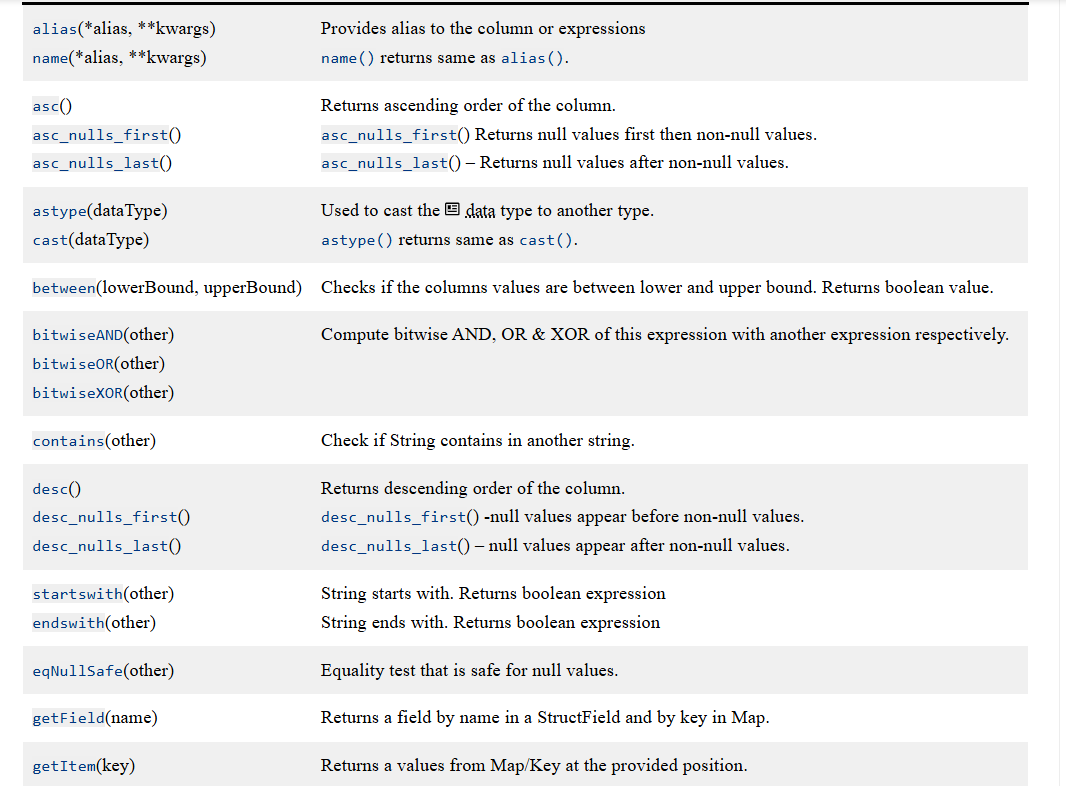

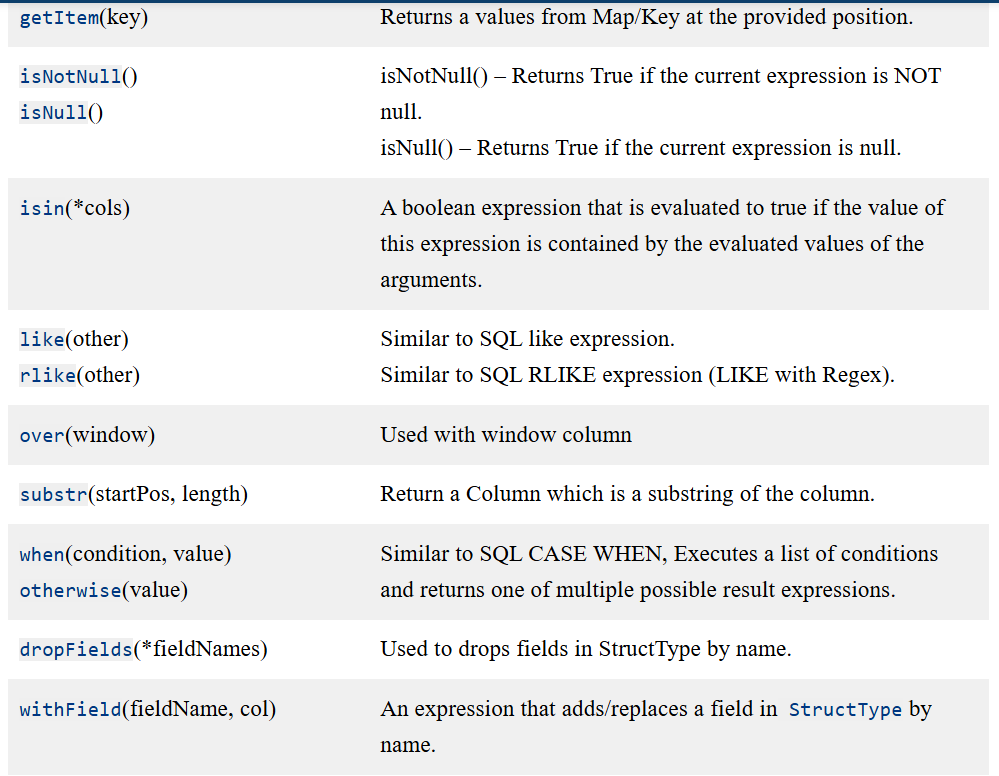

In [31]:
#4. PySpark Column Functions Examples
data=[("James","Bond","100",None),
      ("Ann","Varsa","200",'F'),
      ("Tom Cruise","XXX","400",''),
      ("Tom Brand",None,"400",'M')]
columns=["fname","lname","id","gender"]

df = spark.createDataFrame(data, columns)
df.show()


+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|     James| Bond|100|  NULL|
|       Ann|Varsa|200|     F|
|Tom Cruise|  XXX|400|      |
| Tom Brand| NULL|400|     M|
+----------+-----+---+------+



In [32]:
#4.1 alias() – Set’s name to Column
from pyspark.sql.functions import expr
df.select(df.fname.alias('frist_name'), df.lname.alias('last_name')).show()

+----------+---------+
|frist_name|last_name|
+----------+---------+
|     James|     Bond|
|       Ann|    Varsa|
|Tom Cruise|      XXX|
| Tom Brand|     NULL|
+----------+---------+



In [35]:
#4.2 asc() & desc() – Sort the DataFrame columns by Ascending or Descending order.
df.sort(df.fname.asc()).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|       Ann|Varsa|200|     F|
|     James| Bond|100|  NULL|
| Tom Brand| NULL|400|     M|
|Tom Cruise|  XXX|400|      |
+----------+-----+---+------+



In [36]:
df.sort(df.fname.desc()).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|Tom Cruise|  XXX|400|      |
| Tom Brand| NULL|400|     M|
|     James| Bond|100|  NULL|
|       Ann|Varsa|200|     F|
+----------+-----+---+------+



In [37]:
#4.3 cast() & astype() – Used to convert the data Type.
df.select(df.fname, df.id.cast('int')).printSchema()

root
 |-- fname: string (nullable = true)
 |-- id: integer (nullable = true)



In [40]:
#4.4 between() – Returns a Boolean expression when a column values in between lower and upper bound.
df.filter(df.id.between(100, 200)).show()

+-----+-----+---+------+
|fname|lname| id|gender|
+-----+-----+---+------+
|James| Bond|100|  NULL|
|  Ann|Varsa|200|     F|
+-----+-----+---+------+



In [41]:
#4.5 contains() –Check if a PySpark DataFrame column value contains a string value specified in this function.
df.filter(df.fname.contains("Cruise")).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|Tom Cruise|  XXX|400|      |
+----------+-----+---+------+



In [43]:
#4.6 startswith() & endswith()
df.filter(df.fname.startswith('T')).show()
df.filter(df.fname.endswith('and')).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|Tom Cruise|  XXX|400|      |
| Tom Brand| NULL|400|     M|
+----------+-----+---+------+

+---------+-----+---+------+
|    fname|lname| id|gender|
+---------+-----+---+------+
|Tom Brand| NULL|400|     M|
+---------+-----+---+------+



In [44]:
#4.8 isNull & isNotNull() – Checks if the DataFrame column has NULL or non NULL values.
df.filter(df.lname.isNull()).show()
df.filter(df.lname.isNotNull()).show()

+---------+-----+---+------+
|    fname|lname| id|gender|
+---------+-----+---+------+
|Tom Brand| NULL|400|     M|
+---------+-----+---+------+

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|     James| Bond|100|  NULL|
|       Ann|Varsa|200|     F|
|Tom Cruise|  XXX|400|      |
+----------+-----+---+------+



In [51]:
#4.9 like() & rlike() – Similar to SQL LIKE expression
df.select(df.fname,df.lname,df.id).filter(df.fname.like("%om%")).show()

+----------+-----+---+
|     fname|lname| id|
+----------+-----+---+
|Tom Cruise|  XXX|400|
| Tom Brand| NULL|400|
+----------+-----+---+



In [53]:
#4.10 substr() – Returns a Column after getting sub string from the Column
df.select(df.fname.substr(1,3).alias("substr")).show()

+------+
|substr|
+------+
|   Jam|
|   Ann|
|   Tom|
|   Tom|
+------+



In [58]:
#4.11 when() & otherwise() – It is similar to SQL Case When, executes sequence of expressions until it matches the condition and returns a value when match
from pyspark.sql.functions import when
df.select(df.fname,df.lname,when(df.gender=="M","Male") \
              .when(df.gender=="F","Female") \
              .when(df.gender==None, "Transgender") \
              .otherwise(df.gender).alias("new_gender") \
    ).show()

+----------+-----+----------+
|     fname|lname|new_gender|
+----------+-----+----------+
|     James| Bond|      NULL|
|       Ann|Varsa|    Female|
|Tom Cruise|  XXX|          |
| Tom Brand| NULL|      Male|
+----------+-----+----------+



In [59]:
#4.12 isin() – Check if value presents in a List.
#isin
li=["100","200"]
df.select(df.fname,df.lname,df.id) \
  .filter(df.id.isin(li)) \
  .show()

+-----+-----+---+
|fname|lname| id|
+-----+-----+---+
|James| Bond|100|
|  Ann|Varsa|200|
+-----+-----+---+



In [68]:
#4.13 getField() – To get the value by key from MapType column and by stuct child name from StructType column
#Create DataFrame with struct, array & map
from pyspark.sql.types import StructType,StructField,StringType,ArrayType,MapType
data=[(("James","Bond"),["Java","C#"],{'hair':'black','eye':'brown'}),
      (("Ann","Varsa"),[".NET","Python"],{'hair':'brown','eye':'black'}),
      (("Tom Cruise",""),["Python","Scala"],{'hair':'red','eye':'grey'}),
      (("Tom Brand",None),["Perl","Ruby"],{'hair':'black','eye':'blue'})]

schema = StructType([
        StructField('name', StructType([
            StructField('fname', StringType(), True),
            StructField('lname', StringType(), True)])),
        StructField('languages', ArrayType(StringType()),True),
        StructField('properties', MapType(StringType(),StringType()),True)
     ])
df=spark.createDataFrame(data,schema)
df.printSchema()
df.show(truncate=False)

root
 |-- name: struct (nullable = true)
 |    |-- fname: string (nullable = true)
 |    |-- lname: string (nullable = true)
 |-- languages: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- properties: map (nullable = true)
 |    |-- key: string
 |    |-- value: string (valueContainsNull = true)

+-----------------+---------------+-----------------------------+
|name             |languages      |properties                   |
+-----------------+---------------+-----------------------------+
|{James, Bond}    |[Java, C#]     |{eye -> brown, hair -> black}|
|{Ann, Varsa}     |[.NET, Python] |{eye -> black, hair -> brown}|
|{Tom Cruise, }   |[Python, Scala]|{eye -> grey, hair -> red}   |
|{Tom Brand, NULL}|[Perl, Ruby]   |{eye -> blue, hair -> black} |
+-----------------+---------------+-----------------------------+



In [64]:
df.select(df.properties.getField('hair')).show()
df.select(df.name.getField("fname")).show()

+----------------+
|properties[hair]|
+----------------+
|           black|
|           brown|
|             red|
|           black|
+----------------+

+----------+
|name.fname|
+----------+
|     James|
|       Ann|
|Tom Cruise|
| Tom Brand|
+----------+



In [70]:
#4.14 getItem() – To get the value by index from MapType or ArrayTupe & ny key for MapType column.
df.select(df.languages.getItem(1)).show()

+------------+
|languages[1]|
+------------+
|          C#|
|      Python|
|       Scala|
|        Ruby|
+------------+



In [71]:
#getItem() used with MapType
df.select(df.properties.getItem("hair")).show()

+----------------+
|properties[hair]|
+----------------+
|           black|
|           brown|
|             red|
|           black|
+----------------+



#PySpark Row using on DataFrame and RDD


* Earlier to Spark 3.0, when used Row class with named arguments, the fields are sorted by name.
* Since 3.0, Rows created from named arguments are not sorted alphabetically instead they will be ordered in the position entered.
* To enable sorting by names, set the environment variable PYSPARK_ROW_FIELD_SORTING_ENABLED to true.
* Row class provides a way to create a struct-type column as well.

In [74]:
#1. Create a Row Object
from pyspark import Row
row = Row("nirmal", 27)
print(row[0] + ","+str(row[1]))
print(row[0])
print(row[1])


nirmal,27
nirmal
27


In [75]:
row=Row(name="Alice", age=11)
print(row.name)

Alice


In [78]:
row=Row(name=['nirmal', 'kumar'], age=11)
print(row.name)

['nirmal', 'kumar']


In [81]:
#2. Create Custom Class from Row
Person = Row("name", "age")
p1=Person("James", 40)
p2=Person("Alice", 35)
print(p1.name +", "+p2.name)

James, Alice


In [82]:
#3. Using Row class on PySpark RDD
from pyspark.sql import SparkSession, Row
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

data = [Row(name="James,,Smith",lang=["Java","Scala","C++"],state="CA"),
    Row(name="Michael,Rose,",lang=["Spark","Java","C++"],state="NJ"),
    Row(name="Robert,,Williams",lang=["CSharp","VB"],state="NV")]
rdd=spark.sparkContext.parallelize(data)
print(rdd.collect())

[Row(name='James,,Smith', lang=['Java', 'Scala', 'C++'], state='CA'), Row(name='Michael,Rose,', lang=['Spark', 'Java', 'C++'], state='NJ'), Row(name='Robert,,Williams', lang=['CSharp', 'VB'], state='NV')]


In [83]:
#6. Complete Example of PySpark Row usage on RDD & DataFrame
from pyspark.sql import SparkSession, Row

row=Row("James",40)
print(row[0] +","+str(row[1]))
row2=Row(name="Alice", age=11)
print(row2.name)

Person = Row("name", "age")
p1=Person("James", 40)
p2=Person("Alice", 35)
print(p1.name +","+p2.name)

#PySpark Example
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

data = [Row(name="James,,Smith",lang=["Java","Scala","C++"],state="CA"),
    Row(name="Michael,Rose,",lang=["Spark","Java","C++"],state="NJ"),
    Row(name="Robert,,Williams",lang=["CSharp","VB"],state="NV")]

#RDD Example 1
rdd=spark.sparkContext.parallelize(data)
collData=rdd.collect()
print(collData)
for row in collData:
    print(row.name + "," +str(row.lang))

# RDD Example 2
Person=Row("name","lang","state")
data = [Person("James,,Smith",["Java","Scala","C++"],"CA"),
    Person("Michael,Rose,",["Spark","Java","C++"],"NJ"),
    Person("Robert,,Williams",["CSharp","VB"],"NV")]
rdd=spark.sparkContext.parallelize(data)
collData=rdd.collect()
print(collData)
for person in collData:
    print(person.name + "," +str(person.lang))

#DataFrame Example 1
columns = ["name","languagesAtSchool","currentState"]
df=spark.createDataFrame(data)
df.printSchema()
df.show()

collData=df.collect()
print(collData)
for row in collData:
    print(row.name + "," +str(row.lang))

#DataFrame Example 2
columns = ["name","languagesAtSchool","currentState"]
df=spark.createDataFrame(data).toDF(*columns)
df.printSchema()

James,40
Alice
James,Alice
[Row(name='James,,Smith', lang=['Java', 'Scala', 'C++'], state='CA'), Row(name='Michael,Rose,', lang=['Spark', 'Java', 'C++'], state='NJ'), Row(name='Robert,,Williams', lang=['CSharp', 'VB'], state='NV')]
James,,Smith,['Java', 'Scala', 'C++']
Michael,Rose,,['Spark', 'Java', 'C++']
Robert,,Williams,['CSharp', 'VB']
[Row(name='James,,Smith', lang=['Java', 'Scala', 'C++'], state='CA'), Row(name='Michael,Rose,', lang=['Spark', 'Java', 'C++'], state='NJ'), Row(name='Robert,,Williams', lang=['CSharp', 'VB'], state='NV')]
James,,Smith,['Java', 'Scala', 'C++']
Michael,Rose,,['Spark', 'Java', 'C++']
Robert,,Williams,['CSharp', 'VB']
root
 |-- name: string (nullable = true)
 |-- lang: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- state: string (nullable = true)

+----------------+------------------+-----+
|            name|              lang|state|
+----------------+------------------+-----+
|    James,,Smith|[Java, Scala, C++]|   CA|
|  

#PySpark Select Columns From DataFrame

In [84]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

# Data
data = [("James","Smith","USA","CA"),
    ("Michael","Rose","USA","NY"),
    ("Robert","Williams","USA","CA"),
    ("Maria","Jones","USA","FL")
  ]

# Column names
columns = ["firstname","lastname","country","state"]

# Create DataFrame
df = spark.createDataFrame(data = data, schema = columns)
df.show(truncate=False)

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|James    |Smith   |USA    |CA   |
|Michael  |Rose    |USA    |NY   |
|Robert   |Williams|USA    |CA   |
|Maria    |Jones   |USA    |FL   |
+---------+--------+-------+-----+



In [85]:
#1. Select Single & Multiple Columns From PySpark
df.select(df.firstname).show()

+---------+
|firstname|
+---------+
|    James|
|  Michael|
|   Robert|
|    Maria|
+---------+



In [86]:
# Select columns by different ways
df.select("firstname","lastname").show()
df.select(df.firstname,df.lastname).show()
df.select(df["firstname"],df["lastname"]).show()

# By using col() function
from pyspark.sql.functions import col
df.select(col("firstname"),col("lastname")).show()

# Select columns by regular expression
df.select(df.colRegex("`^.*name*`")).show()

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+



In [87]:
#2. Select All Columns From List
df.select('*').show()

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+



In [88]:
df.select(*columns).show()

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+



In [89]:
df.select([col for col in df.columns]).show()

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+



In [92]:
#3. Select Columns by Index
df.select(df.columns[:3]).show(3)

+---------+--------+-------+
|firstname|lastname|country|
+---------+--------+-------+
|    James|   Smith|    USA|
|  Michael|    Rose|    USA|
|   Robert|Williams|    USA|
+---------+--------+-------+
only showing top 3 rows


In [93]:
#3. Select Columns by Index
df.select(df.columns[2:5]).show(3)

+-------+-----+
|country|state|
+-------+-----+
|    USA|   CA|
|    USA|   NY|
|    USA|   CA|
+-------+-----+
only showing top 3 rows


In [94]:
#4. Select Nested Struct Columns from PySpark
# Create DataFrame with nested columns
data = [
        (("James",None,"Smith"),"OH","M"),
        (("Anna","Rose",""),"NY","F"),
        (("Julia","","Williams"),"OH","F"),
        (("Maria","Anne","Jones"),"NY","M"),
        (("Jen","Mary","Brown"),"NY","M"),
        (("Mike","Mary","Williams"),"OH","M")
        ]

from pyspark.sql.types import StructType,StructField, StringType
schema = StructType([
    StructField('name', StructType([
         StructField('firstname', StringType(), True),
         StructField('middlename', StringType(), True),
         StructField('lastname', StringType(), True)
         ])),
     StructField('state', StringType(), True),
     StructField('gender', StringType(), True)
     ])
df2 = spark.createDataFrame(data = data, schema = schema)
df2.printSchema()
df2.show(truncate=False) # shows all columns

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string (nullable = true)
 |    |-- lastname: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)

+----------------------+-----+------+
|name                  |state|gender|
+----------------------+-----+------+
|{James, NULL, Smith}  |OH   |M     |
|{Anna, Rose, }        |NY   |F     |
|{Julia, , Williams}   |OH   |F     |
|{Maria, Anne, Jones}  |NY   |M     |
|{Jen, Mary, Brown}    |NY   |M     |
|{Mike, Mary, Williams}|OH   |M     |
+----------------------+-----+------+



In [99]:
df2.select("name").show()

+--------------------+
|                name|
+--------------------+
|{James, NULL, Smith}|
|      {Anna, Rose, }|
| {Julia, , Williams}|
|{Maria, Anne, Jones}|
|  {Jen, Mary, Brown}|
|{Mike, Mary, Will...|
+--------------------+



In [101]:
df2.select("name.firstname","name.lastname", "name.middlename").show(truncate=False)

+---------+--------+----------+
|firstname|lastname|middlename|
+---------+--------+----------+
|James    |Smith   |NULL      |
|Anna     |        |Rose      |
|Julia    |Williams|          |
|Maria    |Jones   |Anne      |
|Jen      |Brown   |Mary      |
|Mike     |Williams|Mary      |
+---------+--------+----------+



In [102]:
# Select all child columns
df2.select("name.*").show(truncate=False)

+---------+----------+--------+
|firstname|middlename|lastname|
+---------+----------+--------+
|James    |NULL      |Smith   |
|Anna     |Rose      |        |
|Julia    |          |Williams|
|Maria    |Anne      |Jones   |
|Jen      |Mary      |Brown   |
|Mike     |Mary      |Williams|
+---------+----------+--------+



In [103]:
#5. Complete Example
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

data = [("James","Smith","USA","CA"),
    ("Michael","Rose","USA","NY"),
    ("Robert","Williams","USA","CA"),
    ("Maria","Jones","USA","FL")
  ]

columns = ["firstname","lastname","country","state"]
df = spark.createDataFrame(data = data, schema = columns)
df.show(truncate=False)

df.select("firstname").show()

df.select("firstname","lastname").show()

#Using Dataframe object name
df.select(df.firstname,df.lastname).show()

# Using col function
from pyspark.sql.functions import col
df.select(col("firstname"),col("lastname")).show()

data = [(("James",None,"Smith"),"OH","M"),
        (("Anna","Rose",""),"NY","F"),
        (("Julia","","Williams"),"OH","F"),
        (("Maria","Anne","Jones"),"NY","M"),
        (("Jen","Mary","Brown"),"NY","M"),
        (("Mike","Mary","Williams"),"OH","M")
        ]

from pyspark.sql.types import StructType,StructField, StringType
schema = StructType([
    StructField('name', StructType([
         StructField('firstname', StringType(), True),
         StructField('middlename', StringType(), True),
         StructField('lastname', StringType(), True)
         ])),
     StructField('state', StringType(), True),
     StructField('gender', StringType(), True)
     ])

df2 = spark.createDataFrame(data = data, schema = schema)
df2.printSchema()
df2.show(truncate=False) # shows all columns

df2.select("name").show(truncate=False)
df2.select("name.firstname","name.lastname").show(truncate=False)
df2.select("name.*").show(truncate=False)

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|James    |Smith   |USA    |CA   |
|Michael  |Rose    |USA    |NY   |
|Robert   |Williams|USA    |CA   |
|Maria    |Jones   |USA    |FL   |
+---------+--------+-------+-----+

+---------+
|firstname|
+---------+
|    James|
|  Michael|
|   Robert|
|    Maria|
+---------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

root
 |-- name: struct (nullable = true)
 |    |-- firstname: string (nullable = true)
 |    |-- middlename: string

#PySpark Collect() – Retrieve data from DataFrame

In [104]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

dept = [("Finance",10), \
    ("Marketing",20), \
    ("Sales",30), \
    ("IT",40) \
  ]
deptColumns = ["dept_name","dept_id"]
deptDF = spark.createDataFrame(data=dept, schema = deptColumns)
deptDF.show(truncate=False)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



In [106]:
datacollect = deptDF.collect()
print(datacollect)

[Row(dept_name='Finance', dept_id=10), Row(dept_name='Marketing', dept_id=20), Row(dept_name='Sales', dept_id=30), Row(dept_name='IT', dept_id=40)]


In [107]:
[Row(dept_name='Finance', dept_id=10),
Row(dept_name='Marketing', dept_id=20),
Row(dept_name='Sales', dept_id=30),
Row(dept_name='IT', dept_id=40)]

[Row(dept_name='Finance', dept_id=10),
 Row(dept_name='Marketing', dept_id=20),
 Row(dept_name='Sales', dept_id=30),
 Row(dept_name='IT', dept_id=40)]

In [108]:
for row in datacollect:
  print(row["dept_name"] + ',' + str(row['dept_id']))

Finance,10
Marketing,20
Sales,30
IT,40


* deptDF.collect() returns Array of Row type.
* deptDF.collect()[0] returns the first element in an array (1st row).
* deptDF.collect[0][0] returns the value of the first row & first column.

In [109]:
#Returns value of First Row, First Column which is "Finance"
deptDF.collect()[0][0]

'Finance'

In [111]:
dataCollect = deptDF.select("dept_name").collect()
dataCollect

[Row(dept_name='Finance'),
 Row(dept_name='Marketing'),
 Row(dept_name='Sales'),
 Row(dept_name='IT')]

When to avoid Collect()
> Usually, collect() is used to retrieve the action output when you have very small result set and calling collect() on an RDD/DataFrame with a bigger result set causes out of memory as it returns the entire dataset (from all workers) to the driver hence we should avoid calling collect() on a larger dataset.

collect () vs select ()
> select() is a transformation that returns a new DataFrame and holds the columns that are selected whereas collect() is an action that returns the entire data set in an Array to the driver.

#PySpark withColumn() Usage with Examples

In [114]:
data = [('James','','Smith','1991-04-01','M',3000),
  ('Michael','Rose','','2000-05-19','M',4000),
  ('Robert','','Williams','1978-09-05','M',4000),
  ('Maria','Anne','Jones','1967-12-01','F',4000),
  ('Jen','Mary','Brown','1980-02-17','F',-1)
]

columns = ["firstname","middlename","lastname","dob","gender","salary"]

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Nirmal').getOrCreate()
df = spark.createDataFrame(data, columns)
df.printSchema()
df.show(truncate=False)


root
 |-- firstname: string (nullable = true)
 |-- middlename: string (nullable = true)
 |-- lastname: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: long (nullable = true)

+---------+----------+--------+----------+------+------+
|firstname|middlename|lastname|dob       |gender|salary|
+---------+----------+--------+----------+------+------+
|James    |          |Smith   |1991-04-01|M     |3000  |
|Michael  |Rose      |        |2000-05-19|M     |4000  |
|Robert   |          |Williams|1978-09-05|M     |4000  |
|Maria    |Anne      |Jones   |1967-12-01|F     |4000  |
|Jen      |Mary      |Brown   |1980-02-17|F     |-1    |
+---------+----------+--------+----------+------+------+



In [117]:
#1. Change DataType using PySpark withColumn()
df.withColumn("salary",col("salary").cast("Integer")).show()

+---------+----------+--------+----------+------+------+
|firstname|middlename|lastname|       dob|gender|salary|
+---------+----------+--------+----------+------+------+
|    James|          |   Smith|1991-04-01|     M|  3000|
|  Michael|      Rose|        |2000-05-19|     M|  4000|
|   Robert|          |Williams|1978-09-05|     M|  4000|
|    Maria|      Anne|   Jones|1967-12-01|     F|  4000|
|      Jen|      Mary|   Brown|1980-02-17|     F|    -1|
+---------+----------+--------+----------+------+------+



In [118]:
#2. Update The Value of an Existing Column
df.withColumn("salary", col('salary')*100).show()

+---------+----------+--------+----------+------+------+
|firstname|middlename|lastname|       dob|gender|salary|
+---------+----------+--------+----------+------+------+
|    James|          |   Smith|1991-04-01|     M|300000|
|  Michael|      Rose|        |2000-05-19|     M|400000|
|   Robert|          |Williams|1978-09-05|     M|400000|
|    Maria|      Anne|   Jones|1967-12-01|     F|400000|
|      Jen|      Mary|   Brown|1980-02-17|     F|  -100|
+---------+----------+--------+----------+------+------+



In [119]:
#3. Create a Column from an Existing
df.withColumn("CopiedColumn",col("salary")* -1).show()

+---------+----------+--------+----------+------+------+------------+
|firstname|middlename|lastname|       dob|gender|salary|CopiedColumn|
+---------+----------+--------+----------+------+------+------------+
|    James|          |   Smith|1991-04-01|     M|  3000|       -3000|
|  Michael|      Rose|        |2000-05-19|     M|  4000|       -4000|
|   Robert|          |Williams|1978-09-05|     M|  4000|       -4000|
|    Maria|      Anne|   Jones|1967-12-01|     F|  4000|       -4000|
|      Jen|      Mary|   Brown|1980-02-17|     F|    -1|           1|
+---------+----------+--------+----------+------+------+------------+



In [120]:
#4. Add a New Column using withColumn()
df.withColumn("Country", lit("USA")).show()

+---------+----------+--------+----------+------+------+-------+
|firstname|middlename|lastname|       dob|gender|salary|Country|
+---------+----------+--------+----------+------+------+-------+
|    James|          |   Smith|1991-04-01|     M|  3000|    USA|
|  Michael|      Rose|        |2000-05-19|     M|  4000|    USA|
|   Robert|          |Williams|1978-09-05|     M|  4000|    USA|
|    Maria|      Anne|   Jones|1967-12-01|     F|  4000|    USA|
|      Jen|      Mary|   Brown|1980-02-17|     F|    -1|    USA|
+---------+----------+--------+----------+------+------+-------+



In [123]:
df.withColumn("Country", lit("USA")) \
  .withColumn("State",lit("Saint Paul")) \
  .show()

+---------+----------+--------+----------+------+------+-------+----------+
|firstname|middlename|lastname|       dob|gender|salary|Country|     State|
+---------+----------+--------+----------+------+------+-------+----------+
|    James|          |   Smith|1991-04-01|     M|  3000|    USA|Saint Paul|
|  Michael|      Rose|        |2000-05-19|     M|  4000|    USA|Saint Paul|
|   Robert|          |Williams|1978-09-05|     M|  4000|    USA|Saint Paul|
|    Maria|      Anne|   Jones|1967-12-01|     F|  4000|    USA|Saint Paul|
|      Jen|      Mary|   Brown|1980-02-17|     F|    -1|    USA|Saint Paul|
+---------+----------+--------+----------+------+------+-------+----------+



In [125]:
#5. Rename Column Name
df.withColumnRenamed("gender", 'sex').show()

+---------+----------+--------+----------+---+------+
|firstname|middlename|lastname|       dob|sex|salary|
+---------+----------+--------+----------+---+------+
|    James|          |   Smith|1991-04-01|  M|  3000|
|  Michael|      Rose|        |2000-05-19|  M|  4000|
|   Robert|          |Williams|1978-09-05|  M|  4000|
|    Maria|      Anne|   Jones|1967-12-01|  F|  4000|
|      Jen|      Mary|   Brown|1980-02-17|  F|    -1|
+---------+----------+--------+----------+---+------+



In [126]:
df.withColumnsRenamed({'sex':'gender', 'dob':'date of birth'}).show()

+---------+----------+--------+-------------+------+------+
|firstname|middlename|lastname|date of birth|gender|salary|
+---------+----------+--------+-------------+------+------+
|    James|          |   Smith|   1991-04-01|     M|  3000|
|  Michael|      Rose|        |   2000-05-19|     M|  4000|
|   Robert|          |Williams|   1978-09-05|     M|  4000|
|    Maria|      Anne|   Jones|   1967-12-01|     F|  4000|
|      Jen|      Mary|   Brown|   1980-02-17|     F|    -1|
+---------+----------+--------+-------------+------+------+



In [127]:
#6. Drop Column From PySpark DataFrame
df.drop(df.middlename).show()

+---------+--------+----------+------+------+
|firstname|lastname|       dob|gender|salary|
+---------+--------+----------+------+------+
|    James|   Smith|1991-04-01|     M|  3000|
|  Michael|        |2000-05-19|     M|  4000|
|   Robert|Williams|1978-09-05|     M|  4000|
|    Maria|   Jones|1967-12-01|     F|  4000|
|      Jen|   Brown|1980-02-17|     F|    -1|
+---------+--------+----------+------+------+

